    Name: Sienna Joya Haag
    Username: sjhaag
    Student number: S6214320
    Group (AS1, etc.): AS1


In [ ]:
# 6.1
from astropy.io import fits
import numpy as np
import scipy.stats as sp
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

k = fits.open("m101.fits")
k.info()
print(k[0].header[0:5])

dat = k[0].data
print(dat.shape)
print(dat.dtype)

zm = dat.flatten()
# print(sp.describe(zm))
ma, mi,mean,std, med, mode = round(zm.max(),2) , round(zm.min(), 2), round(np.mean(zm), 2), round(np.std(zm), 2), round(np.median(zm), 2), sp.mode(zm).mode
print(f"Max = {ma}, min = {mi}, mean = {mean}, standard deviation = {std}, median = {med}, mode = {mode}")

fig, ax = plt.subplots()
ax.hist(zm, bins = 50)
ax.axvline(mean, label = f"Mean = {mean}", color = 'red')
ax.axvline(med, label = f"Median = {med}", color = 'g')
ax.axvline(mode, label = f"Mode = {mode}", color = 'purple')
ax.legend()
fig.show()

fig2, ax2 = plt.subplots()
im = np.asarray(dat, dtype = "float64")
image = ax2.imshow(im, vmin = med)
ax2.set_xlabel(k[0].header['CTYPE1'])
ax2.set_ylabel(k[0].header['CTYPE2'])
divider = make_axes_locatable(ax2)
colbarframe = divider.append_axes("right", 0.4)
fig2.colorbar(image, label = "Counts", cax=colbarframe)

k[0].header["BUNIT"] = "Counts"
print(k[0].header["BUNIT"])
k.close()
n = fits.PrimaryHDU(data = im)

There are 2 HDUs.

The first HDU, index 0


int16

BITPIX= 16,  the data type corresponds with the data type found in the previous question

The dimension is 530x530 as expeted

NAXIS = 530x530, so it is as expected

dtype >i2 means int16, as expected

In [ ]:
# 6.3
from astropy.io import fits
import numpy as np
import scipy.stats as sp
import matplotlib.pyplot as plt

k = fits.open("m101.fits")
dat = k[0].data
im = np.asarray(dat, dtype = "float64")
fig, ax = plt.subplots()
ax.imshow(im[0:20, 0:20])
small = im[0:20, 0:20]

x = np.sqrt((np.mean(small**2)))
print(x)
print(np.mean(small))
print(np.std(small))
k.close()

The standard deviation is different from the RMS value because it aims to give an average of the values, while the standard deviaton gives an idea of how uch the values vary. 

The standard deviation quantifies the noise best as it gives the how much the counts vary from the mean. 

In [ ]:
# 6.5
from astropy.io import fits
import numpy as np
import scipy.stats as sp
import matplotlib.pyplot as plt

noise0 = fits.open("noisemap0.fits")
noise1 = fits.open("noisemap1.fits")
noise2 = fits.open("noisemap2.fits")

d0 = noise0[0].data
d1 = noise1[0].data
d2 = noise2[0].data

st0 = np.std(d0)
st1 = np.std(d1)
st2 = np.std(d2)

d = np.stack((d0, d1, d2), axis = 0)
m = np.mean(d, axis = 0)
stm = np.std(m)
st = np.sqrt(st0**2+st1**2+st2**2)/3
print(stm)
print(st)

noise0.close()
noise1.close()
noise2.close()

In [ ]:
# 6.6
from astropy.io import fits
from astropy.table import Column, Table
import numpy as np

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

flag = (data['STARFLAG'] == 0) & (data['ASPCAPFLAG'] == 0) & (data['SNR'] > 10) & (data["GAIAEDR3_PARALLAX"]/data["GAIAEDR3_PARALLAX_ERROR"] > 5) & (~np.isnan(data["GAIAEDR3_PHOT_G_MEAN_MAG"])) & (~np.isnan(data["GAIAEDR3_PHOT_BP_MEAN_MAG"])) & (~np.isnan(data["GAIAEDR3_PHOT_RP_MEAN_MAG"]))
dataflag = Column(flag.astype(int), name = 'DATAFLAG')
datat = Table(data)
datat.add_column(dataflag)

absM = np.where(datat['DATAFLAG'] == 0, -1.0, datat["GAIAEDR3_PHOT_G_MEAN_MAG"]+5*np.log10(datat["GAIAEDR3_PARALLAX"]/1000)+5)
absMc = Column(absM, name = 'ABS MAGNITUDE')
datat.add_column(absMc)

datat.write('APOGEE_update.fits', format='fits')


42489404.0
    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  
25.68840037029544


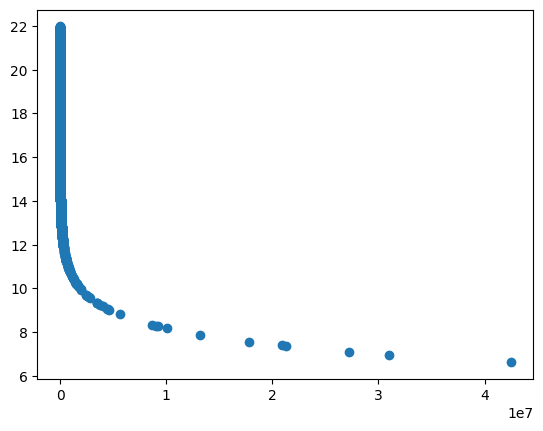

In [4]:
# 6.7
import csv
import pandas
import numpy as np
import matplotlib.pyplot as plt

gaia = pandas.read_csv('gaiaTestData.csv')
gaiapanda = pandas.DataFrame(gaia)
maxv = np.max(gaiapanda["phot_g_mean_flux"])
print(maxv)
ind = gaiapanda.index[gaiapanda["phot_g_mean_flux"] == maxv].tolist()

r = gaiapanda[gaiapanda.isin([maxv]).any(axis=1)]
print(r)

sorted = gaiapanda.sort_values("phot_g_mean_flux")
flux = gaiapanda["phot_g_mean_flux"]
mag = gaiapanda['phot_g_mean_mag']
fig, ax = plt.subplots()
ax.scatter(flux, mag)

m0 = mag + 2.5*np.log10(flux)
meanm0 = np.mean(m0)
print(meanm0)

In [5]:
# 6.10
from astroquery.gaia import Gaia
query = """
SELECT TOP 50
    source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax/ parallax_error > 5
    AND phot_g_mean_mag IS NOT NULL
    AND phot_bp_mean_mag IS NOT NULL
    AND phot_rp_mean_mag IS NOT NULL
ORDER BY random_index
"""

job = Gaia.launch_job(query)
results = job.get_results()
gaia = results.to_pandas()

results.write("astroquery_gaia.fits", format='fits')

/Software/users/modules/9/software/anaconda3/2023.03/lib/python3.10/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.11.909) or chardet (4.0.0)/charset_normalizer (2.0.4) doesn't match a supported version!
  warnings.warn(


OSError: File astroquery_gaia.fits already exists. If you mean to replace it then use the argument "overwrite=True".

In [10]:
# 6.14
class Fibonacci:

    def __init__(self, N, M):
        self.N = N
        self.M = M
        
    def nth(self):
        i = 0
        b = 1
        a = 0
        Nth = 0
        while i < self.N :
            Nth = a + b
            a = b
            b = Nth
            i = i + 1
        return Nth
    
    def divM(self):
        allF = []
        Nth = 0
        j = 0
        b = 1
        a = 0
        Nth = 0
        while j < self.N :
            Nth = a + b
            a = b
            b = Nth
            if Nth%self.M == 0:
                allF.append(Nth)
            j = j + 1
        return allF
fib = Fibonacci(100, 7)
print(fib.nth())
print(fib.divM())

573147844013817084101
[21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
